# 11_数据预处理方法-数据标准化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天就数据预处理技巧中的数据标准化和大家好好聊聊\~

简单来说，数据标准化其实就是把数据转换到同一个尺度上，让各个数据特征之间可以平等地比较和运算，不会因为量纲（单位）或者数值范围不同而影响分析或模型训练的结果。

#### 为什么需要数据标准化？

- **消除量纲影响**：不同的特征可能原本单位和数值范围差距很大（比如身高、体重、收入），不进行标准化的话，数值大的特征会对模型产生过大的影响。
- **提高模型稳定性**：很多算法（如梯度下降优化算法、支持向量机、K近邻算法等）都对数据的尺度敏感，标准化后的数据能帮助算法更快、更好地收敛。
- **方便比较**：经过标准化处理后的数据一般会以零为中心，标准差为1，这样不同数据之间就可以直接比较了。

#### 数据标准化的常见方法

最常用的方法就是**Z-Score标准化**（也称为标准差标准化），计算公式为：


$$
z = \frac{x - \mu}{\sigma}
$$


其中：

- $x$是原始数据
- $\mu$是数据的均值
- $\sigma$是数据的标准差

通过这个公式，原始数据会转变为新的数据 $z$，它表示原数据距离均值的标准差倍数。这样处理后的数据大致分布在[-3, 3]的范围内（根据正态分布的特性）。

### 举例说明

假设我们有一组简单的数据，表示三个学生的数学成绩：70分、80分、90分。下面我们用 Z-Score 标准化方法来处理这组数据。

1. **计算均值** $\mu$：  
$\mu = \frac{70 + 80 + 90}{3} = \frac{240}{3} = 80$
2. **计算标准差** $\sigma$：  
$\sigma = \sqrt{\frac{(70-80)^2 + (80-80)^2 + (90-80)^2}{3}} = \sqrt{\frac{100 + 0 + 100}{3}} = \sqrt{\frac{200}{3}} \approx 8.165$
3. **对每个数据进行标准化**：

   - 对于70分：$z = \frac{70 - 80}{8.165} \approx \frac{-10}{8.165} \approx -1.225$
   - 对于80分：$z = \frac{80 - 80}{8.165} = 0$
   - 对于90分：$z = \frac{90 - 80}{8.165} \approx \frac{10}{8.165} \approx 1.225$

- **结果说明**：经过标准化后，70分对应的标准分数大约是-1.225，说明它比平均成绩低了1.225个标准差；90分对应的标准分数大约是1.225，说明它比平均成绩高了1.225个标准差；80分正好是平均值，所以标准分数为0。
- **直观理解**：通过标准化，原本70、80、90的成绩就变成了一个统一的标准，可以更直观地看到每个数据相对于整体的偏离程度。如果再加入其他不同量纲的数据（比如英语成绩），这种处理方式就能保证各项特征在模型中有类似的影响力，而不会因为数值大小不同而“抢占风头”。

这种处理方式对于很多机器学习算法来说非常重要，极大程度上能够帮助算法更好地学习和预测。

## 公式解析

在机器学习或数据分析中，不同特征可能具有不同的量纲和数值范围。这会导致某些特征对模型训练起主导作用，而忽略了其他特征。

为了解决这一问题，我们通常希望将数据转换到同一尺度下，使得数据满足零均值和单位方差。

标准化后的数据可以直接比较，并且能提高许多算法（如梯度下降法、支持向量机、K近邻算法等）的性能和稳定性。

### Z-Score标准化公式

给定一个数据集：


$$
X = \{x_1, x_2, \dots, x_n\}
$$


Z-Score标准化的公式为：


$$
z_i = \frac{x_i - \mu}{\sigma},\quad i=1,2,\dots,n
$$


其中：

- $x_i$ 表示原始数据中的第 $i$ 个样本；
- $\mu$ 是所有样本的均值：


$$
\mu = \frac{1}{n}\sum_{i=1}^{n} x_i
$$


- $\sigma$ 是样本的标准差，计算方式为：


$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$


### 详细公式推导

#### 1. 目标：数据变换为零均值、单位方差

我们希望经过变换后的数据 $z_i$ 满足：

- 均值为 0：$\frac{1}{n}\sum_{i=1}^{n}z_i = 0$
- 方差为 1：$\frac{1}{n}\sum_{i=1}^{n}(z_i-0)^2 = 1$

#### 2. 均值归一化（中心化）

首先，对原始数据做中心化：


$$
x'_i = x_i - \mu
$$


这样变换后的数据 $x'_i$ 均值为：


$$
\frac{1}{n}\sum_{i=1}^{n} x'_i = \frac{1}{n}\sum_{i=1}^{n} (x_i - \mu) = \mu - \mu = 0
$$


#### 3. 缩放到单位方差

接下来，需要对中心化后的数据进行缩放，使得它们的方差为 1。

计算中心化后数据的标准差：


$$
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
$$


然后，将中心化后的数据除以标准差：


$$
z_i = \frac{x'_i}{\sigma} = \frac{x_i - \mu}{\sigma}
$$


变换后的数据 $z_i$ 的方差为：


$$
\frac{1}{n}\sum_{i=1}^{n}z_i^2 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \mu}{\sigma}\right)^2 = \frac{1}{\sigma^2}\left(\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2\right) = \frac{\sigma^2}{\sigma^2} = 1
$$


这样，就满足了零均值和单位方差的要求。

### 步骤总结

1. **计算均值**：  
$\mu = \frac{1}{n}\sum_{i=1}^{n}x_i$
2. **计算标准差**：  
$\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}$
3. **标准化数据**：  
对每个 $x_i$，计算  
$z_i = \frac{x_i - \mu}{\sigma}$

经过以上步骤，所有 $z_i$ 构成的新数据集具有均值0、方差1。

### Min-Max归一化

除了Z-Score标准化，另一种常见的方法是Min-Max归一化，它将数据缩放到指定区间（通常为$0,1$）。

公式为：


$$
x'_i = \frac{x_i - \min(X)}{\max(X) - \min(X)}
$$


这种方法适用于对数据的最值敏感的情况，但与Z-Score标准化不同，它不能保证数据呈正态分布。

总的来说，**Z-Score标准化**通过减去均值和除以标准差，将数据转换为零均值、单位方差，使得数据在同一尺度上比较，减少量纲和数值范围差异的影响。

## 完整案例

代码中先生成一组模拟学生成绩数据，再使用 Z-Score 标准化方法对数据进行预处理\~

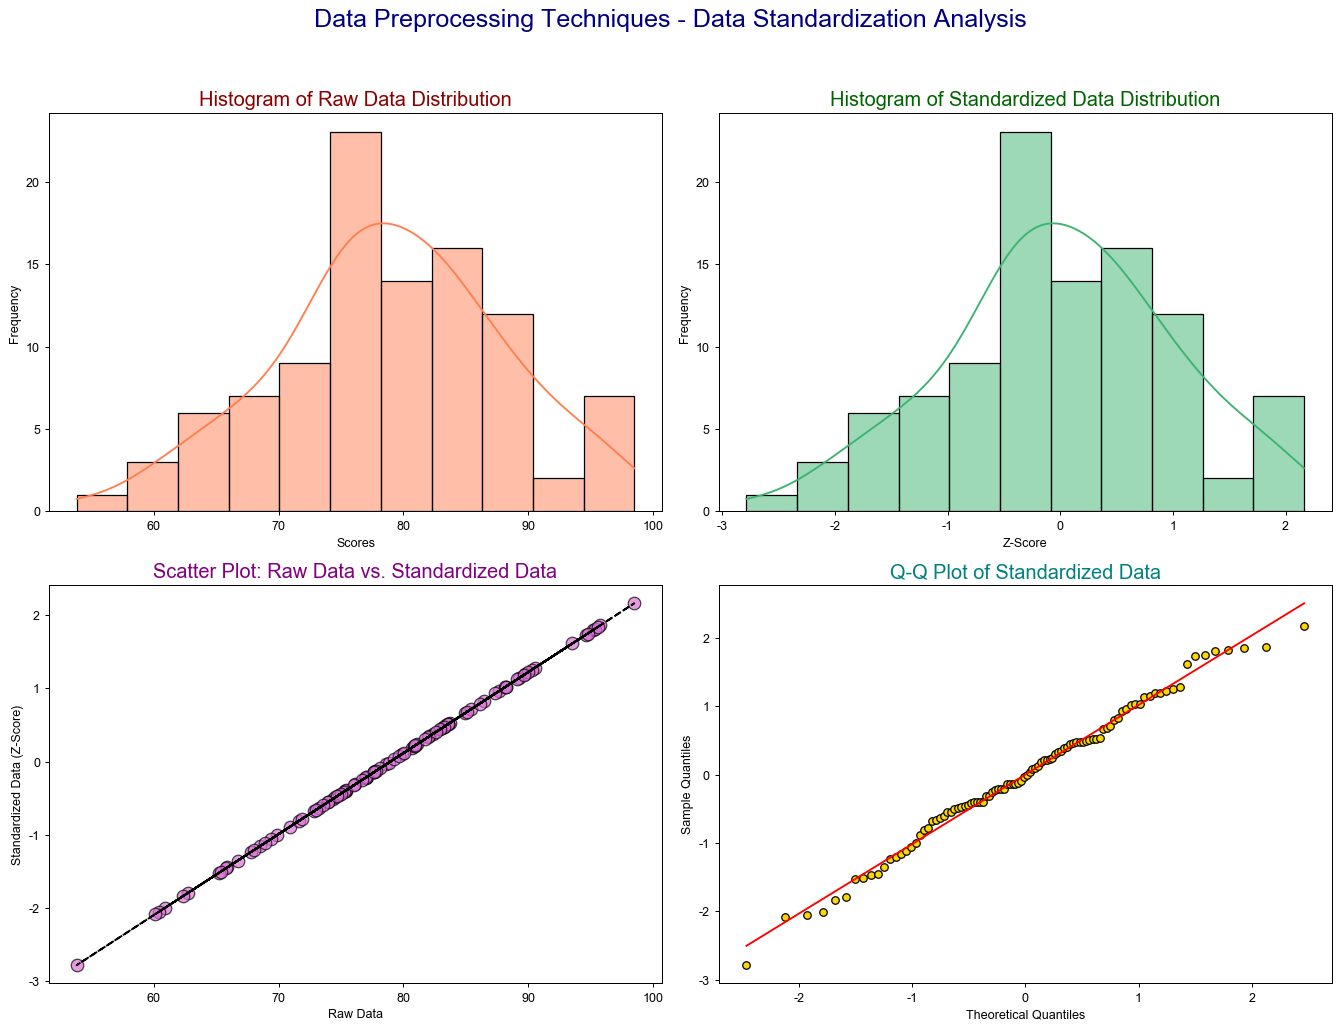

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


# 生成模拟数据：100个学生的数学成绩，均值80，标准差10
np.random.seed(42)  # 保证结果可复现
data = np.random.normal(loc=80, scale=10, size=100)

# 数据标准化（Z-Score方法）
mu = np.mean(data)
sigma = np.std(data)
z_data = (data - mu) / sigma

# 创建一个2x2的子图，共4个图形
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Data Preprocessing Techniques - Data Standardization Analysis", fontsize=20, color='navy')

# 图1：原始数据直方图（带核密度估计曲线）
sns.histplot(data, kde=True, color="coral", ax=axes[0, 0])
axes[0, 0].set_title("Histogram of Raw Data Distribution", fontsize=16, color='darkred')
axes[0, 0].set_xlabel("Scores")
axes[0, 0].set_ylabel("Frequency")

# 图2：标准化数据直方图（带核密度估计曲线）
sns.histplot(z_data, kde=True, color="mediumseagreen", ax=axes[0, 1])
axes[0, 1].set_title("Histogram of Standardized Data Distribution", fontsize=16, color='darkgreen')
axes[0, 1].set_xlabel("Z-Score")
axes[0, 1].set_ylabel("Frequency")

# 图3：原始数据与标准化数据散点图（并添加参考拟合直线）
axes[1, 0].scatter(data, z_data, color="orchid", edgecolor='black', s=100, alpha=0.7)
axes[1, 0].set_title("Scatter Plot: Raw Data vs. Standardized Data", fontsize=16, color='purple')
axes[1, 0].set_xlabel("Raw Data")
axes[1, 0].set_ylabel("Standardized Data (Z-Score)")
# 添加拟合直线作为参考
m, b = np.polyfit(data, z_data, 1)
axes[1, 0].plot(data, m * data + b, color="black", linestyle="--")

# 图4：标准化数据 Q-Q 图，检验是否服从正态分布
stats.probplot(z_data, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Standardized Data", fontsize=16, color='teal')
# 修改 Q-Q 图中散点和直线的样式
qq_points = axes[1, 1].get_lines()[0]
qq_points.set_markerfacecolor('gold')
qq_points.set_markeredgecolor('black')
qq_line = axes[1, 1].get_lines()[1]
qq_line.set_color('red')
axes[1, 1].set_xlabel("Theoretical Quantiles")
axes[1, 1].set_ylabel("Sample Quantiles")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**数据生成与标准化**：使用 `np.random.normal` 生成了 100 个均值为 80、标准差为 10 的数据，并通过公式  
$z = \frac{x - \mu}{\sigma}$  
得到标准化后的数据。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

- **直方图**：使用 seaborn 的 `histplot` 绘制原始数据和标准化数据的分布，并显示核密度估计曲线，使分布更直观。
- **散点图**：绘制原始数据与标准化数据之间的关系，同时添加了线性拟合直线，以展示二者的线性变换关系。
- **Q-Q 图**：利用 `scipy.stats.probplot` 绘制标准化数据的 Q-Q 图，用于验证数据是否符合正态分布。

大家可以直观地理解数据标准化前后的数据分布和特征。